In [2]:
import pandas as pd
import os

# current dataset path
dataset_path = "/content/drive/MyDrive/00 IITR INTERNSHIP/00 Datasets/00_final_dataset_transformer.csv"

df = pd.read_csv(dataset_path)

print("Original shape:", df.shape)

# 1️⃣ remove empty rows
# df = df.dropna(subset=["text", "family"])

# 2️⃣ remove duplicate APKs
# df = df.drop_duplicates(subset=["file_name"])

# 3️⃣ normalize text
df["text"] = df["text"].str.lower()

# 4️⃣ remove extra spaces
df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

# 5️⃣ remove extremely short samples
df["text_length"] = df["text"].str.split().apply(len)

df = df[df["text_length"] > 20]

print("Cleaned shape:", df.shape)

# remove helper column
df = df.drop(columns=["text_length"])

# 6️⃣ save cleaned dataset in same directory
save_path = os.path.join(os.path.dirname(dataset_path),
                         "cleaned_dataset_transformer.csv")

df.to_csv(save_path, index=False)

print("Cleaned dataset saved at:")
print(save_path)

Original shape: (4990, 3)
Cleaned shape: (4964, 4)
Cleaned dataset saved at:
/content/drive/MyDrive/00 IITR INTERNSHIP/00 Datasets/cleaned_dataset_transformer.csv


In [6]:
print(df["text"][0])

PERM: INTERNET ACCESS_NETWORK_STATE CALL_PHONE SEND_SMS WRITE_EXTERNAL_STORAGE VIBRATE READ_PHONE_STATE KILL_BACKGROUND_PROCESSES READ_CONTACTS READ_LOGS WRITE_CONTACTS ACCESS_WIFI_STATE RECEIVE_SMS INSTALL_SHORTCUT GET_TASKS SYSTEM_ALERT_WINDOW MODIFY_PHONE_STATE RESTART_PACKAGES MODIFY_AUDIO_SETTINGS WAKE_LOCK CHANGE_WIFI_STATE RECEIVE_BOOT_COMPLETED UNINSTALL_SHORTCUT API: forceLoad setInternalPageChangeListener executePendingBroadcasts infoForPosition getFragment onProgressUpdate onStopLoading onHiddenChanged setPassword createSDDir getMaxScrollX setBreadCrumbTitle setPageTransformer dumpViewHierarchy setNumber getCallingActivity onMenuItemSelected access$102 onSizeChanged setViewText registerReceiver removeAtRange startActivities valueAt restoreViewState run performDrag takeContentChanged getInfo onAdapterChanged addTab newOnQueryTextListener getString getNotification setFocused isAdded dispatchContextItemSelected setStream onClick setShowAsAction setSortOrder onBackStackChanged a

Token length statistics:
count     4990.000000
mean      2317.513627
std       3881.652184
min         13.000000
25%        159.000000
50%        497.000000
75%       2259.000000
max      33312.000000
Name: token_length, dtype: float64

Samples exceeding 512 tokens: 2458


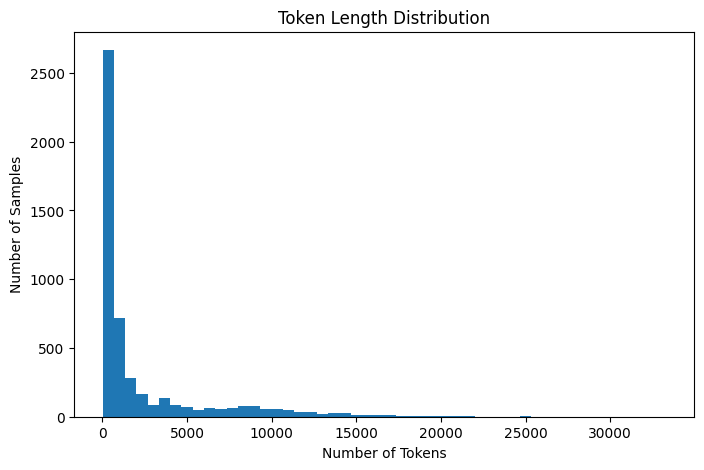

In [3]:
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/00 IITR INTERNSHIP/00 Datasets/00_final_dataset_transformer.csv"

df = pd.read_csv(dataset_path)

# calculate token length
df["token_length"] = df["text"].str.split().apply(len)

print("Token length statistics:")
print(df["token_length"].describe())

# check how many exceed BERT limit
over_limit = (df["token_length"] > 512).sum()

print("\nSamples exceeding 512 tokens:", over_limit)

# histogram
plt.figure(figsize=(8,5))
plt.hist(df["token_length"], bins=50)
plt.title("Token Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Samples")
plt.show()

In [4]:
print("90th percentile:", df["token_length"].quantile(0.9))
print(df['family'].value_counts())
print(df.duplicated(subset=['text']).sum())
print(df['token_length'].mean())

90th percentile: 8409.600000000002
family
SMS         1089
Benign      1060
Banking      986
Adware       966
Riskware     889
Name: count, dtype: int64
1979
2317.513627254509


In [8]:
import pandas as pd
import os

dataset_path = "/content/drive/MyDrive/00 IITR INTERNSHIP/00 Datasets/00_final_dataset_transformer.csv"

df = pd.read_csv(dataset_path)

print("Original shape:", df.shape)

# -----------------------------
# 1️⃣ Remove duplicate texts
# -----------------------------

# df = df.drop_duplicates(subset=["text"])

print("After removing duplicates:", df.shape)

# -----------------------------
# 2️⃣ Function to extract sections
# -----------------------------

def clean_text_pipeline(text):

    try:

        # split sections
        perm_part = text.split("PERM:")[1].split("API:")[0]
        api_part = text.split("API:")[1].split("INTENT:")[0]
        intent_part = text.split("INTENT:")[1].split("OPCODE:")[0]
        opcode_part = text.split("OPCODE:")[1]

        # tokenize
        perms = perm_part.strip().split()
        apis = api_part.strip().split()
        intents = intent_part.strip().split()
        opcodes = opcode_part.strip().split()

        # limit API calls
        apis = apis[:150]
        opcodes = opcodes[:200]

        # rebuild cleaned text
        clean_text = (
            "PERMISSION " + " ".join(perms) +
            " API " + " ".join(apis) +
            " INTENT " + " ".join(intents) +
            " OPCODE " + " ".join(opcodes)
        )

        return clean_text

    except:
        return None


# -----------------------------
# 3️⃣ Apply cleaning
# -----------------------------

df["clean_text"] = df["text"].apply(clean_text_pipeline)

df = df.dropna(subset=["clean_text"])

# -----------------------------
# 4️⃣ Token length analysis
# -----------------------------

df["token_length"] = df["clean_text"].str.split().apply(len)

print("\nToken statistics:")
print(df["token_length"].describe())

print("\n90th percentile:",
      df["token_length"].quantile(0.9))

# -----------------------------
# 5️⃣ Remove extremely long samples
# -----------------------------

df = df[df["token_length"] <= 512]

print("\nAfter removing long samples:", df.shape)

# -----------------------------
# 6️⃣ Prepare final dataset
# -----------------------------

final_df = df[["file_name", "family", "clean_text"]]

final_df = final_df.rename(columns={"clean_text": "text"})

# -----------------------------
# 7️⃣ Save cleaned dataset
# -----------------------------

save_path = os.path.join(
    os.path.dirname(dataset_path),
    "transformer_dataset_cleaned.csv"
)

final_df.to_csv(save_path, index=False)

print("\nClean dataset saved at:")
print(save_path)

Original shape: (4990, 3)
After removing duplicates: (4990, 3)

Token statistics:
count    4990.000000
mean      206.853908
std        66.169896
min        13.000000
25%       159.000000
50%       235.000000
75%       252.000000
max       478.000000
Name: token_length, dtype: float64

90th percentile: 271.0

After removing long samples: (4990, 5)

Clean dataset saved at:
/content/drive/MyDrive/00 IITR INTERNSHIP/00 Datasets/transformer_dataset_cleaned.csv


In [10]:
df = pd.read_csv("/content/drive/MyDrive/00 IITR INTERNSHIP/00 Datasets/transformer_dataset_cleaned.csv")
df["text"][0]

'PERMISSION INTERNET ACCESS_NETWORK_STATE CALL_PHONE SEND_SMS WRITE_EXTERNAL_STORAGE VIBRATE READ_PHONE_STATE KILL_BACKGROUND_PROCESSES READ_CONTACTS READ_LOGS WRITE_CONTACTS ACCESS_WIFI_STATE RECEIVE_SMS INSTALL_SHORTCUT GET_TASKS SYSTEM_ALERT_WINDOW MODIFY_PHONE_STATE RESTART_PACKAGES MODIFY_AUDIO_SETTINGS WAKE_LOCK CHANGE_WIFI_STATE RECEIVE_BOOT_COMPLETED UNINSTALL_SHORTCUT API forceLoad setInternalPageChangeListener executePendingBroadcasts infoForPosition getFragment onProgressUpdate onStopLoading onHiddenChanged setPassword createSDDir getMaxScrollX setBreadCrumbTitle setPageTransformer dumpViewHierarchy setNumber getCallingActivity onMenuItemSelected access$102 onSizeChanged setViewText registerReceiver removeAtRange startActivities valueAt restoreViewState run performDrag takeContentChanged getInfo onAdapterChanged addTab newOnQueryTextListener getString getNotification setFocused isAdded dispatchContextItemSelected setStream onClick setShowAsAction setSortOrder onBackStackChan